In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np
import concurrent.futures
from sklearn.linear_model import LinearRegression


In [2]:
# Load the dataset
data = pd.read_csv("RFLFSODataFull.csv")

In [71]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 91379 entries, 0 to 91378
Data columns (total 27 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   FSO_Att                91379 non-null  float64
 1   RFL_Att                91379 non-null  float64
 2   AbsoluteHumidity       91379 non-null  float64
 3   AbsoluteHumidityMax    91379 non-null  float64
 4   AbsoluteHumidityMin    91379 non-null  float64
 5   Distance               91379 non-null  float64
 6   Frequency              91379 non-null  int64  
 7   Particulate            91379 non-null  float64
 8   ParticulateMax         91379 non-null  float64
 9   ParticulateMin         91379 non-null  float64
 10  RainIntensity          91379 non-null  float64
 11  RainIntensityMax       91379 non-null  float64
 12  RainIntensityMin       91379 non-null  float64
 13  RelativeHumidity       91379 non-null  float64
 14  SYNOPCode              91379 non-null  int64  
 15  Te

In [3]:
data.head()

,FSO_Att,RFL_Att,AbsoluteHumidity,AbsoluteHumidityMax,AbsoluteHumidityMin,Distance,Frequency,Particulate,ParticulateMax,ParticulateMin,...,TemperatureMax,TemperatureMin,Time,Visibility,VisibilityMax,VisibilityMin,WindDirection,WindSpeed,WindSpeedMax,WindSpeedMin
0,7.913289,6.927868,17.595709,17.615907,17.340148,2115.338398,83500000000,0.0,0.0,0.0,...,26.603030,24.680849,9,65884.51846,72336.362233,65617.543754,88.755450,3.057066,6.863808,3.007939
1,7.451176,4.412096,17.549693,17.572415,17.299439,2113.999257,73500000000,0.0,0.0,0.0,...,26.377164,24.313108,9,64963.41092,68753.386153,60379.327485,99.790057,2.727910,6.468903,2.537393
2,7.072747,6.268740,17.290230,17.644014,16.037894,2118.689047,83500000000,0.0,0.0,0.0,...,27.670822,23.150277,10,54794.28107,54821.773817,50850.155963,65.730085,1.674810,2.826916,1.640809
3,6.949288,4.317853,16.820880,17.066776,15.895622,2114.632339,73500000000,0.0,0.0,0.0,...,26.522100,23.174815,10,50205.64159,52519.927530,45374.510898,88.127497,0.962068,2.780643,0.886951
4,7.361052,6.114514,16.813820,17.953974,15.227225,2116.786055,83500000000,0.0,0.0,0.0,...,26.305736,24.864100,10,59038.32599,64418.329138,54461.246506,84.167414,1.881007,4.476298,1.874052


In [4]:
data.describe()

,FSO_Att,RFL_Att,AbsoluteHumidity,AbsoluteHumidityMax,AbsoluteHumidityMin,Distance,Frequency,Particulate,ParticulateMax,ParticulateMin,...,TemperatureMax,TemperatureMin,Time,Visibility,VisibilityMax,VisibilityMin,WindDirection,WindSpeed,WindSpeedMax,WindSpeedMin
count,91379.000000,91379.000000,91379.000000,91379.000000,91379.000000,91379.000000,9.137900e+04,91379.000000,91379.000000,91379.000000,...,91379.000000,91379.000000,91379.000000,91379.000000,91379.000000,91379.000000,91379.000000,91379.000000,91379.000000,91379.000000
mean,6.769458,11.619098,9.553919,10.032760,9.076251,3297.930328,7.850005e+10,27.065979,28.417120,25.717089,...,13.166020,11.904558,11.373193,32986.417484,34636.684647,31331.618978,89.043304,0.739065,1.851020,0.702242
std,3.903843,3.438873,5.858577,6.162798,5.575927,1224.305893,5.000027e+09,72.134023,75.761896,68.595239,...,9.589755,8.694028,6.942229,24713.874445,25978.845228,23497.873065,26.415610,0.871314,1.762698,0.828796
min,0.788363,0.027142,1.141556,1.238270,1.049744,2012.000148,7.350000e+10,0.000000,0.000000,0.000000,...,-6.693373,-7.270075,0.000000,10.151990,11.029667,9.484346,0.000000,0.000000,0.000000,0.000000
25%,3.473063,10.829331,4.958993,5.205861,4.709511,2019.431812,7.350000e+10,0.000000,0.000000,0.000000,...,4.905387,4.438425,5.000000,11158.598400,11721.447542,10588.793237,82.976727,0.076749,0.512667,0.072912
50%,6.336167,11.856560,6.870737,7.205499,6.524046,2959.863686,8.350000e+10,0.000000,0.000000,0.000000,...,10.803943,9.774467,11.000000,26378.636210,27686.214032,25047.188462,90.867362,0.437995,1.323101,0.416274
75%,8.664984,12.847944,14.049470,14.782679,13.379256,4820.890157,8.350000e+10,16.947618,17.775980,16.038090,...,22.470382,20.322434,17.000000,53493.821285,56092.212376,50797.690402,98.482652,1.088621,2.681788,1.036574
max,32.455222,46.893150,24.790883,26.407305,24.268431,4827.999971,8.350000e+10,1621.001906,1753.747866,1500.666382,...,40.771383,36.724191,23.000000,75004.999150,82503.130084,74999.343414,360.000000,7.799086,16.421115,7.252319


In [5]:
data.isna().sum()

FSO_Att                  0
RFL_Att                  0
AbsoluteHumidity         0
AbsoluteHumidityMax      0
AbsoluteHumidityMin      0
Distance                 0
Frequency                0
Particulate              0
ParticulateMax           0
ParticulateMin           0
RainIntensity            0
RainIntensityMax         0
RainIntensityMin         0
RelativeHumidity         0
SYNOPCode                0
Temperature              0
TemperatureDifference    0
TemperatureMax           0
TemperatureMin           0
Time                     0
Visibility               0
VisibilityMax            0
VisibilityMin            0
WindDirection            0
WindSpeed                0
WindSpeedMax             0
WindSpeedMin             0
dtype: int64

In [6]:
def backward_selection(X, y, n_estimators=100):
    """Perform backward selection using Random Forest feature importances with thread pooling."""
    # Initialize variables
    remaining_features = list(X.columns)
    best_features = remaining_features.copy()
    best_score = float('inf')  # Start with a high score for RMSE
    scores = []
    r2_scores = []

    def fit_and_evaluate(features):
        """Fit the model and evaluate it using the provided features."""
        model = RandomForestRegressor(n_estimators=n_estimators, random_state=42)
        X_train, X_test, y_train, y_test = train_test_split(X[features], y, test_size=0.2, random_state=42)
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        rmse = np.sqrt(mean_squared_error(y_test, y_pred))
        r2 = r2_score(y_test, y_pred)
        return model, features, rmse, r2

    while len(remaining_features) > 0:
        with concurrent.futures.ThreadPoolExecutor() as executor:
            future = executor.submit(fit_and_evaluate, remaining_features)
            model, features, rmse, r2 = future.result()

        # Evaluate the model
        scores.append((remaining_features.copy(), rmse))
        r2_scores.append((remaining_features.copy(), r2))

        # Check if the current model is better than the best one found so far
        if rmse < best_score:
            best_score = rmse
            best_features = remaining_features.copy()

        # Get feature importances and find the least important feature
        importances = model.feature_importances_
        least_important_feature = remaining_features[np.argmin(importances)]

        # Remove the least important feature
        remaining_features.remove(least_important_feature)

    return best_features, scores, r2_scores




In [7]:
# Define the set of predictor variables and target variables
predictor_variables = data.drop(columns=['FSO_Att', 'RFL_Att', 'Time'])  # Exclude target and 'Time'
target_fso = data['FSO_Att']
target_rfl = data['RFL_Att']


In [8]:
# Perform backward selection for FSO and RFL
best_features_fso, scores_fso, r2_scores_fso = backward_selection(predictor_variables, target_fso)
best_features_rfl, scores_rfl, r2_scores_rfl = backward_selection(predictor_variables, target_rfl)

In [9]:
# Display the results
best_features_fso, best_features_rfl, scores_fso[:5], r2_scores_fso[:5], scores_rfl[:5], r2_scores_rfl[:5]

(['AbsoluteHumidity',
  'AbsoluteHumidityMax',
  'Distance',
  'Particulate',
  'ParticulateMax',
  'ParticulateMin',
  'RelativeHumidity',
  'Temperature',
  'TemperatureDifference',
  'TemperatureMax',
  'TemperatureMin',
  'Visibility',
  'VisibilityMax',
  'VisibilityMin',
  'WindSpeed',
  'WindSpeedMax'],
 ['AbsoluteHumidity',
  'AbsoluteHumidityMin',
  'Distance',
  'Frequency',
  'ParticulateMax',
  'RainIntensity',
  'RainIntensityMax',
  'RainIntensityMin',
  'RelativeHumidity',
  'SYNOPCode',
  'Temperature',
  'TemperatureDifference',
  'TemperatureMax',
  'Visibility'],
 [(['AbsoluteHumidity',
    'AbsoluteHumidityMax',
    'AbsoluteHumidityMin',
    'Distance',
    'Frequency',
    'Particulate',
    'ParticulateMax',
    'ParticulateMin',
    'RainIntensity',
    'RainIntensityMax',
    'RainIntensityMin',
    'RelativeHumidity',
    'SYNOPCode',
    'Temperature',
    'TemperatureDifference',
    'TemperatureMax',
    'TemperatureMin',
    'Visibility',
    'VisibilityMa

In [36]:
best_features_rfl

['AbsoluteHumidity',
 'AbsoluteHumidityMin',
 'Distance',
 'Frequency',
 'ParticulateMax',
 'RainIntensity',
 'RainIntensityMax',
 'RainIntensityMin',
 'RelativeHumidity',
 'SYNOPCode',
 'Temperature',
 'TemperatureDifference',
 'TemperatureMax',
 'Visibility']

In [10]:
scores_fso[:5], r2_scores_fso[:5], scores_rfl[:5], r2_scores_rfl[:5]

([(['AbsoluteHumidity',
    'AbsoluteHumidityMax',
    'AbsoluteHumidityMin',
    'Distance',
    'Frequency',
    'Particulate',
    'ParticulateMax',
    'ParticulateMin',
    'RainIntensity',
    'RainIntensityMax',
    'RainIntensityMin',
    'RelativeHumidity',
    'SYNOPCode',
    'Temperature',
    'TemperatureDifference',
    'TemperatureMax',
    'TemperatureMin',
    'Visibility',
    'VisibilityMax',
    'VisibilityMin',
    'WindDirection',
    'WindSpeed',
    'WindSpeedMax',
    'WindSpeedMin'],
   np.float64(0.8986704214833798)),
  (['AbsoluteHumidity',
    'AbsoluteHumidityMax',
    'AbsoluteHumidityMin',
    'Distance',
    'Particulate',
    'ParticulateMax',
    'ParticulateMin',
    'RainIntensity',
    'RainIntensityMax',
    'RainIntensityMin',
    'RelativeHumidity',
    'SYNOPCode',
    'Temperature',
    'TemperatureDifference',
    'TemperatureMax',
    'TemperatureMin',
    'Visibility',
    'VisibilityMax',
    'VisibilityMin',
    'WindDirection',
    'Wind

In [32]:
# Convert results to DataFrames for easier inspection
scores_fso = pd.DataFrame(scores_fso, columns=['Features', 'RMSE'])
r2_scores_fso = pd.DataFrame(r2_scores_fso, columns=['Features', 'R2'])
scores_rfl_df = pd.DataFrame(scores_rfl, columns=['Features', 'RMSE'])
r2_scores_rfl_df = pd.DataFrame(r2_scores_rfl, columns=['Features', 'R2'])



In [33]:
scores_rfl_df

,Features,RMSE
0,"[AbsoluteHumidity, AbsoluteHumidityMax, Absolu...",0.521625
1,"[AbsoluteHumidity, AbsoluteHumidityMax, Absolu...",0.520006
2,"[AbsoluteHumidity, AbsoluteHumidityMax, Absolu...",0.519128
3,"[AbsoluteHumidity, AbsoluteHumidityMax, Absolu...",0.520392
4,"[AbsoluteHumidity, AbsoluteHumidityMax, Absolu...",0.519566
5,"[AbsoluteHumidity, AbsoluteHumidityMax, Absolu...",0.524464
6,"[AbsoluteHumidity, AbsoluteHumidityMax, Absolu...",0.518259
7,"[AbsoluteHumidity, AbsoluteHumidityMax, Absolu...",0.517470
8,"[AbsoluteHumidity, AbsoluteHumidityMax, Absolu...",0.518008
9,"[AbsoluteHumidity, AbsoluteHumidityMin, Distan...",0.510795


In [34]:
r2_scores_rfl_df

,Features,R2
0,"[AbsoluteHumidity, AbsoluteHumidityMax, Absolu...",0.977031
1,"[AbsoluteHumidity, AbsoluteHumidityMax, Absolu...",0.977173
2,"[AbsoluteHumidity, AbsoluteHumidityMax, Absolu...",0.977250
3,"[AbsoluteHumidity, AbsoluteHumidityMax, Absolu...",0.977139
4,"[AbsoluteHumidity, AbsoluteHumidityMax, Absolu...",0.977212
5,"[AbsoluteHumidity, AbsoluteHumidityMax, Absolu...",0.976780
6,"[AbsoluteHumidity, AbsoluteHumidityMax, Absolu...",0.977326
7,"[AbsoluteHumidity, AbsoluteHumidityMax, Absolu...",0.977395
8,"[AbsoluteHumidity, AbsoluteHumidityMax, Absolu...",0.977348
9,"[AbsoluteHumidity, AbsoluteHumidityMin, Distan...",0.977975


In [29]:
scores_fso["Features"][0]

['AbsoluteHumidity',
 'AbsoluteHumidityMax',
 'AbsoluteHumidityMin',
 'Distance',
 'Frequency',
 'Particulate',
 'ParticulateMax',
 'ParticulateMin',
 'RainIntensity',
 'RainIntensityMax',
 'RainIntensityMin',
 'RelativeHumidity',
 'SYNOPCode',
 'Temperature',
 'TemperatureDifference',
 'TemperatureMax',
 'TemperatureMin',
 'Visibility',
 'VisibilityMax',
 'VisibilityMin',
 'WindDirection',
 'WindSpeed',
 'WindSpeedMax',
 'WindSpeedMin']

In [21]:
import matplotlib.pyplot as plt

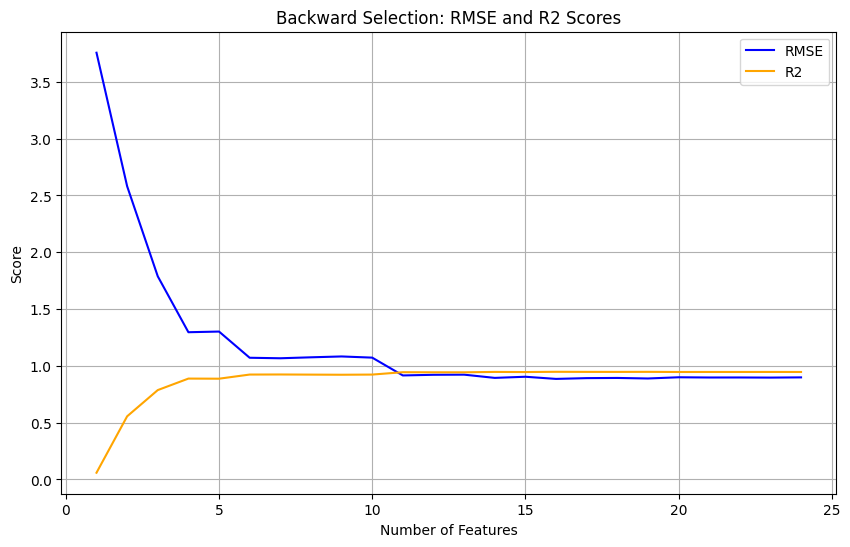

In [23]:
features_list = [len(features) for features in scores_rfl_df['Features']]

plt.figure(figsize=(10, 6))

# Plot RMSE
plt.plot(features_list, scores_fso['RMSE'], label='RMSE', color='blue')

# Plot R-Squared
plt.plot(features_list, r2_scores_fso['R2'], label='R2', color='orange')

plt.xlabel('Number of Features')
plt.ylabel('Score')
plt.title('Backward Selection: RMSE and R2 Scores')
plt.legend(loc='upper right')
plt.grid(True)
plt.show()

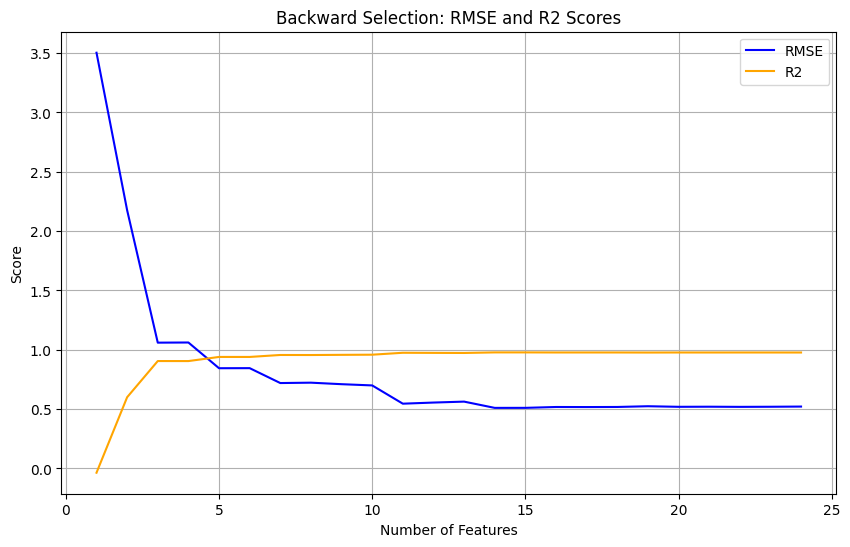

In [35]:
features_list = [len(features) for features in scores_rfl_df['Features']]

plt.figure(figsize=(10, 6))

# Plot RMSE
plt.plot(features_list, scores_rfl_df['RMSE'], label='RMSE', color='blue')

# Plot R-Squared
plt.plot(features_list, r2_scores_rfl_df['R2'], label='R2', color='orange')

plt.xlabel('Number of Features')
plt.ylabel('Score')
plt.title('Backward Selection: RMSE and R2 Scores')
plt.legend(loc='upper right')
plt.grid(True)
plt.show()

In [40]:
# Important features
important_features = [
    'AbsoluteHumidity', 'AbsoluteHumidityMin', 'Distance', 'Frequency', 'ParticulateMax',
    'RainIntensity', 'RainIntensityMax', 'RainIntensityMin', 'RelativeHumidity',
    'SYNOPCode', 'Temperature', 'TemperatureDifference', 'TemperatureMax', 'Visibility'
]

In [42]:
smaller_data = data[important_features]

In [43]:
smaller_data.head()

,AbsoluteHumidity,AbsoluteHumidityMin,Distance,Frequency,ParticulateMax,RainIntensity,RainIntensityMax,RainIntensityMin,RelativeHumidity,SYNOPCode,Temperature,TemperatureDifference,TemperatureMax,Visibility
0,17.595709,17.340148,2115.338398,83500000000,0.0,0.0,0.0,0.0,71.974648,0,26.067846,13.63,26.603030,65884.51846
1,17.549693,17.299439,2113.999257,73500000000,0.0,0.0,0.0,0.0,73.502401,0,25.645703,-0.54,26.377164,64963.41092
2,17.290230,16.037894,2118.689047,83500000000,0.0,0.0,0.0,0.0,72.384543,0,25.653383,-0.24,27.670822,54794.28107
3,16.820880,15.895622,2114.632339,73500000000,0.0,0.0,0.0,0.0,70.447710,0,25.646271,-0.16,26.522100,50205.64159
4,16.813820,15.227225,2116.786055,83500000000,0.0,0.0,0.0,0.0,70.312385,0,25.673089,-0.10,26.305736,59038.32599


In [65]:
filtered_df = smaller_data.query('SYNOPCode == 9')
filtered_df

,AbsoluteHumidity,AbsoluteHumidityMin,Distance,Frequency,ParticulateMax,RainIntensity,RainIntensityMax,RainIntensityMin,RelativeHumidity,SYNOPCode,Temperature,TemperatureDifference,TemperatureMax,Visibility


In [67]:
# Separate the target variable and features
X = smaller_data
y = data['RFL_Att']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [68]:
# Display the shapes of the training and testing sets
(X_train.shape, X_test.shape, y_train.shape, y_test.shape)

((73103, 14), (18276, 14), (73103,), (18276,))

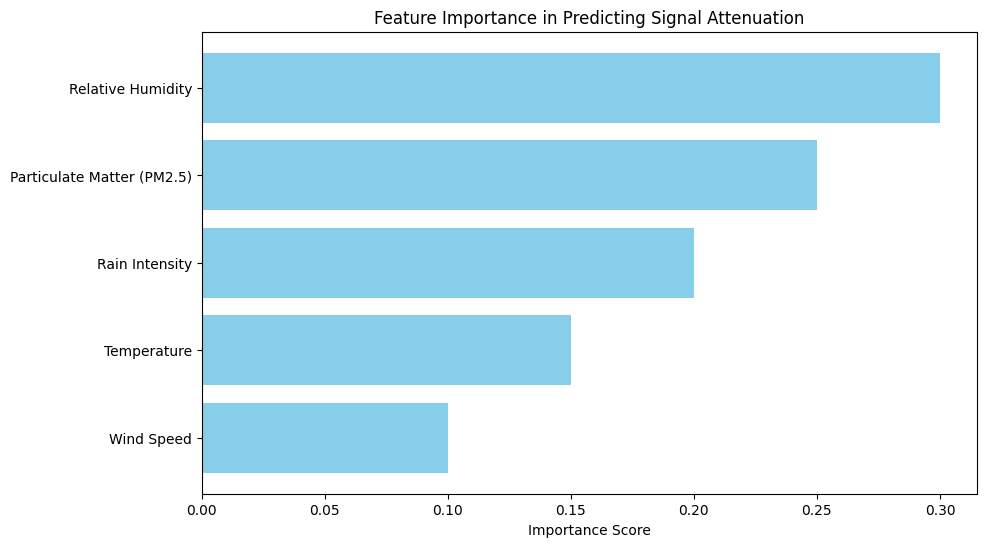

In [72]:
import matplotlib.pyplot as plt
import pandas as pd

# Sample feature importance data
features = ['Relative Humidity', 'Particulate Matter (PM2.5)', 'Rain Intensity', 'Temperature', 'Wind Speed']
importance_scores = [0.30, 0.25, 0.20, 0.15, 0.10]

# Plotting the feature importance
plt.figure(figsize=(10, 6))
plt.barh(features, importance_scores, color='skyblue')
plt.xlabel('Importance Score')
plt.title('Feature Importance in Predicting Signal Attenuation')
plt.gca().invert_yaxis()
plt.show()


In [73]:
import numpy as np
import seaborn as sns

# Sample interaction data
humidity = np.linspace(30, 100, 100)
temperature = np.linspace(10, 30, 100)
attenuation = 0.5 * humidity + 0.3 * temperature + np.random.normal(size=100)

# Plotting interaction effect
plt.figure(figsize=(10, 6))
sns.scatterplot(x=humidity, y=temperature, size=attenuation, hue=attenuation, palette='viridis', sizes=(20, 200))
plt.xlabel('Relative Humidity (%)')
plt.ylabel('Temperature (°C)')
plt.title('Interaction Effect of Humidity and Temperature on Signal Attenuation')
plt.show()


ModuleNotFoundError: No module named 'seaborn'

In [74]:


# Assuming you have a DataFrame `df` and a target variable `y`
X = data[important_features]
y = data['RFL_Att']  # Replace with your actual target variable

# Fit a Random Forest model
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X, y)

# Get feature importance
importance = model.feature_importances_

# Create a DataFrame for easy visualization
feature_importance_df = pd.DataFrame({
    'Feature': important_features,
    'Importance': importance
})

# Sort features by importance
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)

# Display the top 5 most important features
top_5_features = feature_importance_df.head(5)
print(top_5_features)


            Feature  Importance
5     RainIntensity    0.274911
0  AbsoluteHumidity    0.245190
2          Distance    0.206790
6  RainIntensityMax    0.069497
7  RainIntensityMin    0.040933


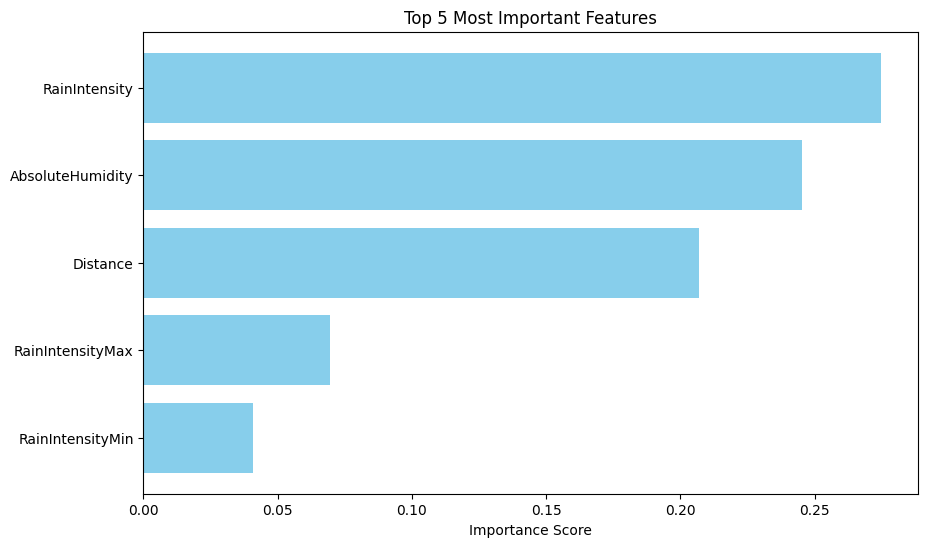

In [75]:
top_5_features = feature_importance_df.head(5)

plt.figure(figsize=(10, 6))
plt.barh(top_5_features['Feature'], top_5_features['Importance'], color='skyblue')
plt.xlabel('Importance Score')
plt.title('Top 5 Most Important Features')
plt.gca().invert_yaxis()
plt.show()

In [76]:


# Assuming you have a DataFrame `df` and a target variable `y`
X = data[important_features]
y = data['FSO_Att']  # Replace with your actual target variable

# Fit a Random Forest model
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X, y)

# Get feature importance
importance = model.feature_importances_

# Create a DataFrame for easy visualization
feature_importance_df = pd.DataFrame({
    'Feature': important_features,
    'Importance': importance
})

# Sort features by importance
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)

# Display the top 5 most important features
top_5_features = feature_importance_df.head(5)
print(top_5_features)


             Feature  Importance
2           Distance    0.347560
13        Visibility    0.246478
10       Temperature    0.133007
4     ParticulateMax    0.125877
0   AbsoluteHumidity    0.034148


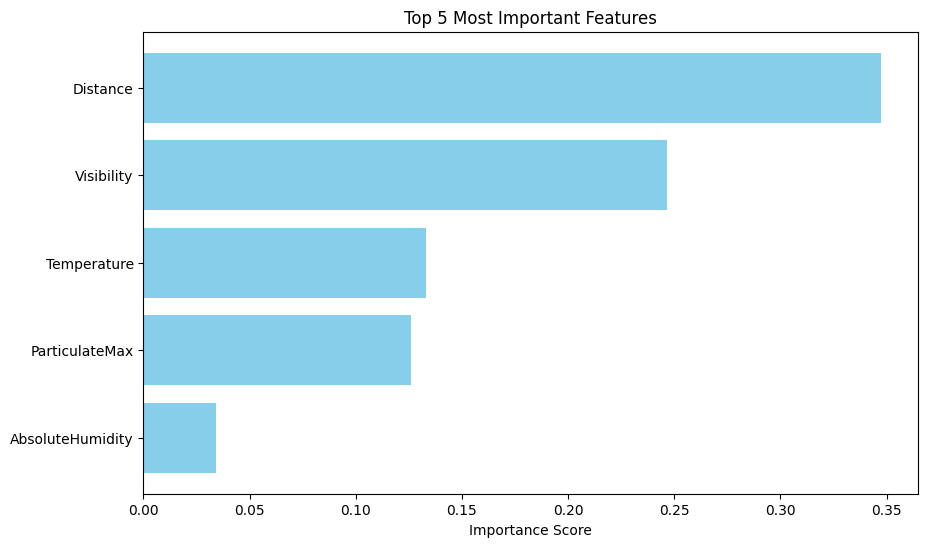

In [77]:
top_5_features = feature_importance_df.head(5)

plt.figure(figsize=(10, 6))
plt.barh(top_5_features['Feature'], top_5_features['Importance'], color='skyblue')
plt.xlabel('Importance Score')
plt.title('Top 5 Most Important Features')
plt.gca().invert_yaxis()
plt.show()